<a href="https://colab.research.google.com/github/huzaifamulla/UIN-231A017-_-NLP-EXPERIMENTS/blob/main/EXP_1_NLP_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud



In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
data = {
    "review": [
        "The product is excellent and amazing",
        "I really love this product",
        "Very good quality and fast delivery",
        "Amazing product, I am very happy",
        "The product is fantastic",
        "Excellent quality and worth the money",
        "I am very satisfied with this purchase",
        "The product works perfectly",
        "Great product and excellent service",
        "I would definitely recommend this product",
        "The quality is outstanding",
        "Very happy with my purchase",
        "The product arrived quickly and works well",
        "Fantastic experience and great quality",
        "This is one of the best products I have purchased",
        "The service was excellent",
        "I am happy with the product",
        "Good product for the price",
        "The product looks beautiful and works perfectly",
        "I am extremely satisfied",

        "Very bad product",
        "I hate this product",
        "The quality is very poor",
        "Waste of money",
        "Very disappointing experience",
        "The product stopped working",
        "I am not satisfied with this product",
        "Terrible quality",
        "The product is useless",
        "Very poor customer service",
        "I regret buying this product",
        "The product broke after one day",
        "Extremely bad experience",
        "The quality is horrible",
        "I would not recommend this product",
        "Very disappointing product",
        "The delivery was late and product was damaged",
        "The product does not work",
        "Poor quality and bad service",
        "Completely dissatisfied",

        "The product was delivered today",
        "I received the product yesterday",
        "The product has two buttons",
        "The package contains a charger",
        "The product is available in black",
        "The box contains the product and manual",
        "The product weighs two kilograms",
        "The delivery arrived in the morning",
        "The product comes with a warranty",
        "The package was delivered to my home",
        "The product has a standard size",
        "The item was ordered online",
        "The product has three different modes",
        "The package includes a cable",
        "The product was purchased last week",
        "The item is currently available",
        "The box was properly sealed",
        "The product was delivered by courier",
        "The device has a charging port",
        "The package contains an instruction manual"
    ],

    "sentiment": (
        ["Positive"] * 20 +
        ["Negative"] * 20 +
        ["Neutral"] * 20
    )
}

df = pd.DataFrame(data)

df.head()

,review,sentiment
0,The product is excellent and amazing,Positive
1,I really love this product,Positive
2,Very good quality and fast delivery,Positive
3,"Amazing product, I am very happy",Positive
4,The product is fantastic,Positive


In [ ]:
print("Number of reviews:", len(df))

print("\nDataset information:")
print(df.info())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Number of reviews: 60

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     60 non-null     object
 1   sentiment  60 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB
None

Sentiment distribution:
sentiment
Positive    20
Negative    20
Neutral     20
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stop words and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["cleaned_review"] = df["review"].apply(preprocess_text)

df[["review", "cleaned_review"]].head(10)

,review,cleaned_review
0,The product is excellent and amazing,product excellent amazing
1,I really love this product,really love product
2,Very good quality and fast delivery,good quality fast delivery
3,"Amazing product, I am very happy",amazing product happy
4,The product is fantastic,product fantastic
5,Excellent quality and worth the money,excellent quality worth money
6,I am very satisfied with this purchase,satisfied purchase
7,The product works perfectly,product work perfectly
8,Great product and excellent service,great product excellent service
9,I would definitely recommend this product,would definitely recommend product


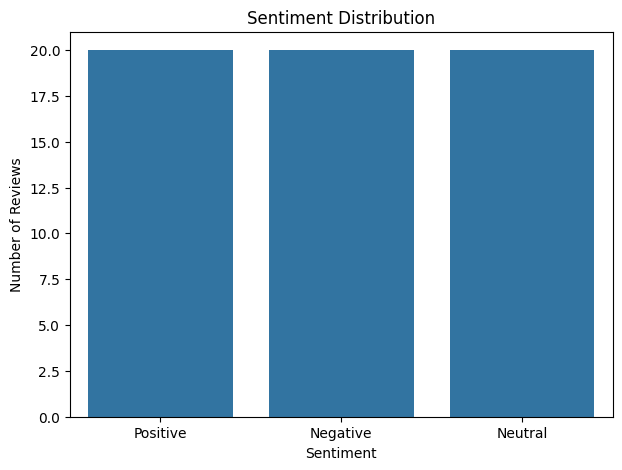

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

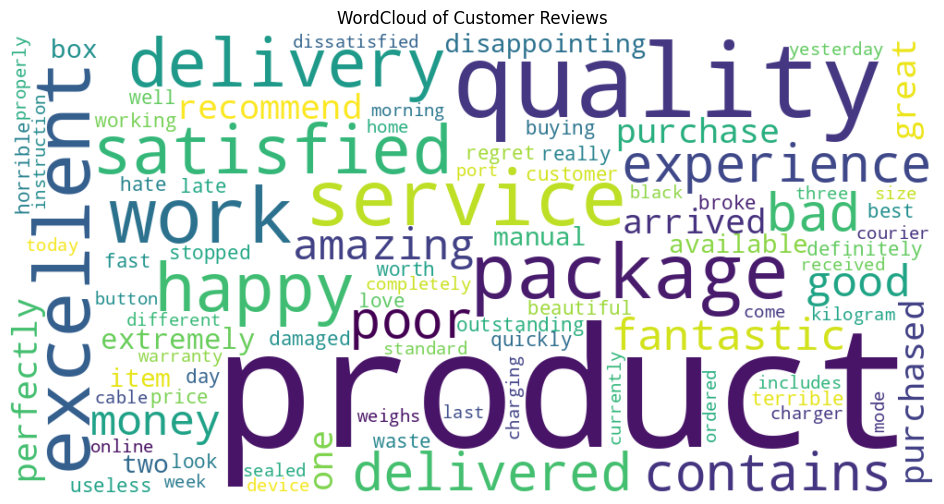

In [ ]:
all_text = " ".join(df["cleaned_review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("WordCloud of Customer Reviews")

plt.show()

In [ ]:
X = df["cleaned_review"]
y = df["sentiment"]

In [ ]:
vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(X)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (60, 92)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 42
Testing samples: 18


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Positive' 'Negative' 'Negative' 'Negative' 'Positive' 'Neutral'
 'Positive' 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Positive' 'Neutral'
 'Negative' 'Positive' 'Positive' 'Negative' 'Neutral']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.6666666666666666
Accuracy Percentage: 66.66666666666666 %


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1-Score: 0.6666666666666666


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.67      0.67      0.67         6
     Neutral       0.67      0.67      0.67         6
    Positive       0.67      0.67      0.67         6

    accuracy                           0.67        18
   macro avg       0.67      0.67      0.67        18
weighted avg       0.67      0.67      0.67        18



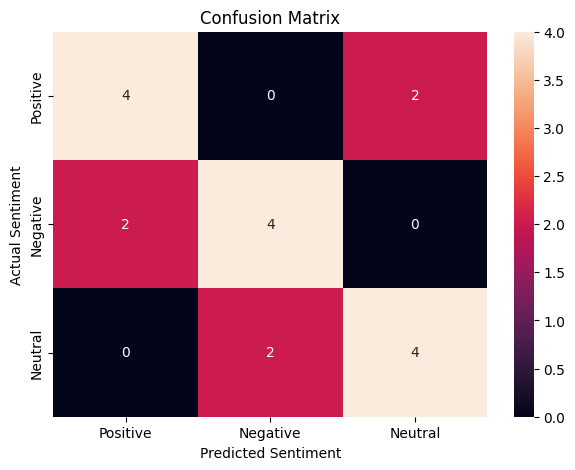

In [ ]:
labels = ["Positive", "Negative", "Neutral"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
def predict_sentiment(review):

    cleaned_review = preprocess_text(review)

    review_tfidf = vectorizer.transform([cleaned_review])

    prediction = model.predict(review_tfidf)

    return prediction[0]

In [ ]:
test_reviews = [
    "I really love this product",
    "This product is terrible and useless",
    "The package was delivered today",
    "Excellent quality and amazing experience",
    "I am very disappointed with this product"
]

for review in test_reviews:
    result = predict_sentiment(review)

    print("Review:", review)
    print("Predicted Sentiment:", result)
    print("-" * 50)

Review: I really love this product
Predicted Sentiment: Positive
--------------------------------------------------
Review: This product is terrible and useless
Predicted Sentiment: Negative
--------------------------------------------------
Review: The package was delivered today
Predicted Sentiment: Neutral
--------------------------------------------------
Review: Excellent quality and amazing experience
Predicted Sentiment: Positive
--------------------------------------------------
Review: I am very disappointed with this product
Predicted Sentiment: Negative
--------------------------------------------------


In [25]:
user_review = input("Enter your customer review: ")

prediction = predict_sentiment(user_review)

print("\nPredicted Sentiment:", prediction)

Enter your customer review: the product is satisfying

Predicted Sentiment: Negative


In [26]:
!pip install gradio

In [31]:
import gradio as gr


# -------------------------------
# SENTIMENT PREDICTION FUNCTION
# -------------------------------

def predict_sentiment(review):

    if review is None or review.strip() == "":
        return "⚠️ Please enter a customer review.", ""

    # Preprocess review
    cleaned_review = preprocess_text(review)

    # TF-IDF transformation
    review_vector = vectorizer.transform([cleaned_review])

    # Predict sentiment
    prediction = model.predict(review_vector)[0]

    # Confidence score
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(review_vector)[0]
        confidence = max(probabilities) * 100
        confidence_text = f"{confidence:.2f}%"
    else:
        confidence_text = "Not available"

    # Sentiment display
    if prediction == "Positive":
        result = "😊 POSITIVE"
    elif prediction == "Negative":
        result = "😞 NEGATIVE"
    else:
        result = "😐 NEUTRAL"

    return result, confidence_text


# -------------------------------
# CLEAR FUNCTION
# -------------------------------

def clear_fields():
    return "", "", ""


# -------------------------------
# CUSTOM CSS
# -------------------------------

custom_css = """
body {
    background: #f4f7fb;
}

.gradio-container {
    max-width: 950px !important;
    margin: auto !important;
}

.title-box {
    text-align: center;
    padding: 25px;
    border-radius: 15px;
    background: linear-gradient(135deg, #667eea, #764ba2);
    color: white;
    margin-bottom: 20px;
}

.review-box {
    border-radius: 12px !important;
}

.result-box {
    border-radius: 12px !important;
    font-size: 20px !important;
    font-weight: bold !important;
}

button {
    border-radius: 10px !important;
}
"""


# -------------------------------
# GRADIO INTERFACE
# -------------------------------

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="blue"
    ),
    css=custom_css,
    title="Sentiment Analysis System"
) as demo:

    # Header
    gr.HTML("""
    <div class="title-box">
        <h1>😊 Customer Review Sentiment Analysis</h1>
        <p>Analyze customer feedback using Natural Language Processing</p>
    </div>
    """)

    gr.Markdown("""
    ### 🔍 Analyze Your Customer Review
    Enter a review below and our machine learning model will predict
    whether the sentiment is **Positive, Negative, or Neutral**.
    """)

    with gr.Row():

        # Left side: Input
        with gr.Column(scale=1):

            review_input = gr.Textbox(
                label="📝 Customer Review",
                placeholder="Example: The product quality is excellent...",
                lines=7,
                elem_classes="review-box"
            )

            analyze_button = gr.Button(
                "🔍 Analyze Sentiment",
                variant="primary",
                size="lg"
            )

            clear_button = gr.Button(
                "🗑️ Clear",
                variant="secondary"
            )

        # Right side: Output
        with gr.Column(scale=1):

            sentiment_output = gr.Textbox(
                label="🎯 Sentiment Result",
                placeholder="Your sentiment result will appear here...",
                lines=3,
                interactive=False,
                elem_classes="result-box"
            )

            confidence_output = gr.Textbox(
                label="📊 Model Confidence",
                placeholder="Confidence score",
                interactive=False
            )

            gr.Markdown("""
            **Possible Sentiments:**

            😊 Positive
            😞 Negative
            😐 Neutral
            """)

    # Examples
    gr.Markdown("### 💡 Try These Examples")





    # Footer
    gr.Markdown("""
    ---
    **Project:** Sentiment Analysis of Customer Reviews Using NLP
    **Model:** TF-IDF + Logistic Regression
    """)

    # Button actions
    analyze_button.click(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=[sentiment_output, confidence_output]
    )

    clear_button.click(
        fn=clear_fields,
        inputs=[],
        outputs=[
            review_input,
            sentiment_output,
            confidence_output
        ]
    )


# -------------------------------
# LAUNCH APPLICATION
# -------------------------------

demo.launch(share=True)

/tmp/ipykernel_3440/4258693781.py:92: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8825dcf93bfc4e5a33.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
